## Business Problem

In [ ]:
	The company has a large amount of customer transaction data, 
	but raw transaction data does not clearly show which customers are valuable, loyal, inactive, or at risk of leaving.
	The business needs a systematic way to understand customer purchasing behavior and divide customers into meaningful groups.

	The project uses RFM Analysis and K-Means Clustering to identify customer segments and provide actionable business recommendations.


## What Are We Trying to Solve?

In [ ]:
## How can we use customer transaction data to identify different types of customers and develop targeted marketing strategies for each group?

## Instead of treating every customer the same, we want to understand their behavior and identify groups such as:

	High-value customers
	Loyal customers
	Recent customers
	Potential customers
	At-risk customers
	Inactive/low-value customers


## Objective

In [ ]:
## The main objectives of this project are:

	Clean and prepare customer transaction data.
	perform Exploratory Data Analysis (EDA).
	Calculate customer-level Recency, Frequency, and Monetary (RFM) metrics.
	Create RFM scores to understand customer behaviour.
	Apply feature engineering and preprocessing.
	Use K-Means Clustering to automatically identify customer groups.
	valuate the quality of different clustering solutions.
	Analyze the characteristics of each customer segment.
	Generate business insights.
	Recommend targeted marketing strategies for each segment



## Key Business Questions

In [ ]:
## Customer Behavior
	Who are our most valuable customers?
	Which customers purchase most frequently?
	Which customers have recently purchased?
	Which customers have not purchased for a long time?

	## Revenue
	Which countries generate the most revenue?
	Which customers contribute the most revenue?
	Are there customers with high purchase frequency but low monetary value?

	## Customer Segmentation
	Can customers be automatically grouped based on their purchasing behavior?
	How many meaningful customer segments exist?
	What are the characteristics of each segment?

	## Business Strategy
	Which customers should receive VIP treatment?
	Which customers should receive retention campaigns?
	Which customers should receive win-back offers?
	Which customers have potential for cross-selling or upselling?


## Dataset Understanding

In [ ]:
#Column	       Description

InvoiceNo	   Unique invoice/transaction number
StockCode	   Product identifier
Description	   Product description
Quantity	   Number of units purchased
InvoiceDate	   Date and time of transaction
UnitPrice	   Price per unit
CustomerID	   Unique customer identifier
Country	       Customer's country

The dataset is used to understand customer purchasing behavior, perform RFM Analysis, and create customer segments using K-Means clustering.

## Data Loading

In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("C:/Users/HP/Desktop/Online Retail DATA.csv")
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.8 MB


In [10]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Cleaning

In [12]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
missing = df.isnull().sum()

missing = missing[
    missing > 0
].sort_values(ascending=False)

missing

CustomerID     135080
Description      1454
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(5268)

In [18]:
df["InvoiceNo"] = (
    df["InvoiceNo"]
    .astype(str)
)
df["InvoiceNo"].head(5)

0    536365
1    536365
2    536365
3    536365
4    536365
Name: InvoiceNo, dtype: str

In [ ]:
## Invoice numbers beginning with C represent cancellations

In [23]:
df["IsCancelled"] = (
    df["InvoiceNo"]
    .str.upper()
    .str.startswith("C")
)
df["IsCancelled"].head()

0    False
1    False
2    False
3    False
4    False
Name: IsCancelled, dtype: bool

In [24]:
df["IsCancelled"].value_counts()

IsCancelled
False    532621
True       9288
Name: count, dtype: int64

In [ ]:
## For our sales analysis

In [28]:
sales_df = df[
    df["IsCancelled"] == False
].copy()
sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,False


In [35]:
sales_df["InvoiceDate"] = pd.to_datetime(
    sales_df["InvoiceDate"],
    format="%d-%m-%Y %H:%M"
)
sales_df["InvoiceDate"].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[us]

In [ ]:
## QUANTITY CLEANING

In [49]:
sales_df[
    sales_df["Quantity"] <= 0
].shape

(0, 9)

In [55]:
sales_df = sales_df[
    sales_df["Quantity"] > 0
].copy()
sales_df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False


In [ ]:
## PRICE CLEANING

In [56]:
sales_df[
    sales_df["UnitPrice"]<=0
    ].head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,False
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,False


In [59]:
sales_df[
    sales_df["UnitPrice"]<=0
    ].shape

(1181, 9)

In [63]:
sales_df = sales_df[
    sales_df["UnitPrice"] > 0
].copy()
sales_df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False


In [64]:
invalid_price_count = (sales_df["UnitPrice"] <= 0).sum()
invalid_price_count

np.int64(0)

In [ ]:
## DUPLICATES

In [65]:
sales_df.duplicated().sum()

np.int64(5226)

In [66]:
sales_df[
    sales_df.duplicated()
    ].head(4)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,False
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,False
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,False
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,False


In [67]:
sales_df = (
    sales_df
    .drop_duplicates()
    .copy()
)
sales_df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False


In [ ]:
## Handling Missing Values

In [68]:
sales_df["Description"].isnull().sum()

np.int64(0)

In [70]:
product_df = sales_df.dropna(
    subset=["Description"]
).copy()
product_df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False


In [79]:
sales_df["CustomerID"].isnull().sum()

np.int64(132186)

In [87]:
Customer_df = sales_df.dropna(
    subset=["CustomerID"]
).copy()
Customer_df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False


In [88]:
Customer_df["CustomerID"].isnull().sum()

np.int64(0)

## REVENUE FEATURE

In [92]:
sales_df["Revenue"] = (
    sales_df["Quantity"]*
    sales_df["UnitPrice"]
)
sales_df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00


In [93]:
sales_df[["Quantity","UnitPrice","Revenue"]].head(3)

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00


## DATE FEATURES

In [97]:
sales_df["Year"] = (sales_df
                    ["InvoiceDate"].dt.year
                   )
sales_df["Year"].head(2)

0    2010
1    2010
Name: Year, dtype: int32

In [100]:
sales_df["Month"] = (sales_df
                     ["InvoiceDate"].dt.month
                    )
sales_df["Month"].head(2)

0    12
1    12
Name: Month, dtype: int32

In [102]:
sales_df["Day"] = (
    sales_df["InvoiceDate"].dt.day
)
sales_df["Day"].head(2)

0    1
1    1
Name: Day, dtype: int32

In [104]:
sales_df["Weekday"] = (
    sales_df["InvoiceDate"].dt.day_name()
)
sales_df["Weekday"].head(2)

0    Wednesday
1    Wednesday
Name: Weekday, dtype: str

In [106]:
sales_df["Hour"] = (
    sales_df["InvoiceDate"].dt.hour
)
sales_df["Hour"].head(2)

0    8
1    8
Name: Hour, dtype: int32

In [108]:
sales_df["MonthYear"] = (
    sales_df["InvoiceDate"]
    .dt.to_period("M")
)
sales_df["MonthYear"].head(2)

0    2010-12
1    2010-12
Name: MonthYear, dtype: period[M]

#### BUSINESS KPIs

In [ ]:
## Total Revenue

In [114]:
Total_revenue = (
    sales_df["Revenue"].sum()
)
print(
    f"Total revenue: £{Total_revenue:,.2f}"
)

Total revenue: £10,642,110.80


In [ ]:
## Total Orders

In [119]:
Total_orders = (
    sales_df["InvoiceNo"].nunique()
)
print(
    f"Total_orders: {Total_orders:,}"
)

Total_orders: 19,960


In [ ]:
## Total Customers 

In [120]:
Total_customers = (
    sales_df["CustomerID"].nunique()
)
print(
    f"Total_customers:{Total_customers:,}"
)

Total_customers:4,338


In [ ]:
## Total Units

In [121]:
Total_units = (
    sales_df["Quantity"].sum()
)
print(
    f"Total_units:{Total_units:,}"
)

Total_units:5,572,420


## Average order Value

In [124]:
order_revenue = (
    sales_df.
        groupby("InvoiceNo")["Revenue"]
    .sum()
)
order_revenue.head(2)

InvoiceNo
536365    139.12
536366     22.20
Name: Revenue, dtype: float64

In [130]:
AOV = order_revenue.mean()
print(
    f"Average order Value:£{AOV:,.2f}"
)

Average order Value:£533.17


## EXPLORATORY DATA ANALYSIS

In [131]:
## Revenue by country

In [136]:
Country_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum().sort_values(
        ascending = False
    )
)
Country_revenue.head(5)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Name: Revenue, dtype: float64

In [ ]:
## Visualization

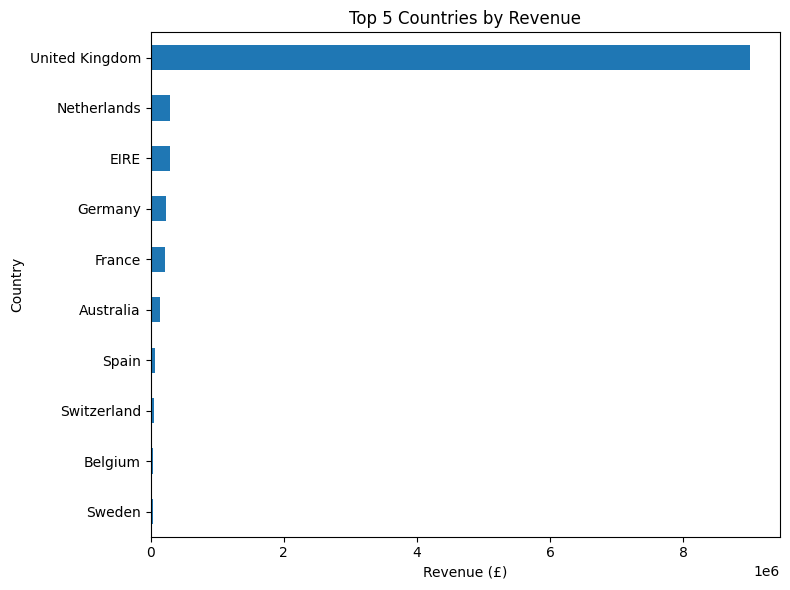

In [140]:
Top_countries = (
    Country_revenue
    .head(15)
    .sort_values()
)

plt.figure(figsize=(8, 6))

top_countries.plot(
    kind="barh"
)

plt.title(
    "Top 5 Countries by Revenue"
)

plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

## PRODUCT ANALYSIS

In [ ]:
## Top Products by Revenue

In [142]:
Product_Revenue = ( 
    sales_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values (ascending = False)
)
Product_Revenue.head(2)

Description
DOTCOM POSTAGE              206248.77
REGENCY CAKESTAND 3 TIER    174156.54
Name: Revenue, dtype: float64

In [ ]:
## Top Products by Quantity

In [146]:
Product_Quantity = (
    sales_df.groupby("Description")["Quantity"]
    .sum().sort_values(ascending = False)
)
Product_Quantity.head(2)

Description
PAPER CRAFT , LITTLE BIRDIE       80995
MEDIUM CERAMIC TOP STORAGE JAR    78033
Name: Quantity, dtype: int64

In [ ]:
## MONTHLY SALES

In [150]:
Monthly_Revenue = (
    sales_df.groupby("MonthYear")["Revenue"].sum()
    .reset_index()
)
Monthly_Revenue.head(2)

,MonthYear,Revenue
0,2010-12,821452.73
1,2011-01,689811.61


In [155]:
Monthly_Revenue["MonthYear"] = (
    Monthly_Revenue["MonthYear"]
    .astype(str)
)
Monthly_Revenue["MonthYear"].head(2)

0    2010-12
1    2011-01
Name: MonthYear, dtype: str

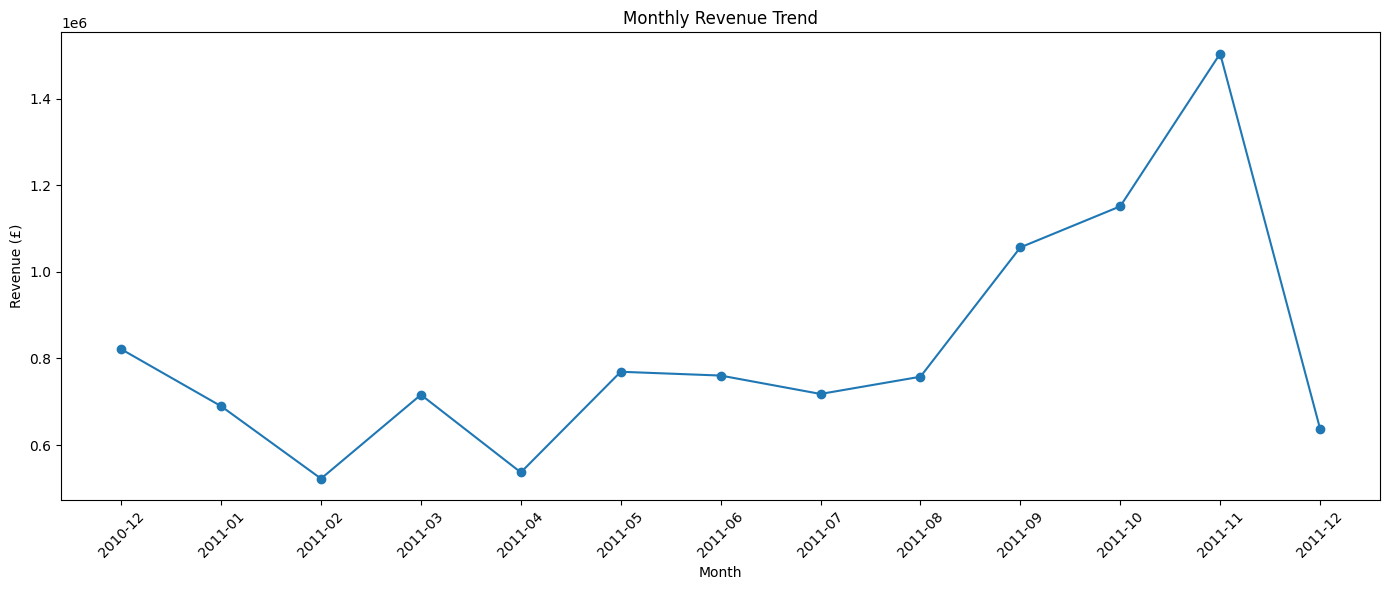

In [156]:
plt.figure(figsize=(14, 6))

plt.plot(
    Monthly_Revenue["MonthYear"],
    Monthly_Revenue["Revenue"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title(
    "Monthly Revenue Trend"
)

plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.tight_layout()
plt.show()

In [ ]:
## Customer Dataset

In [159]:
customer_df = sales_df.dropna(
    subset = ["CustomerID"]
).copy()
customer_df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,Day,Weekday,Hour,MonthYear
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,2010,12,1,Wednesday,8,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010,12,1,Wednesday,8,2010-12


In [ ]:
## Analysis Date

In [166]:
analysis_date = (
    customer_df["InvoiceDate"].max()
+ pd.Timedelta(days=1)
)
analysis_date

Timestamp('2011-12-10 12:50:00')

In [ ]:
## Calculate RFM

In [176]:
RFM = customer_df.groupby(
    "CustomerID"
).agg({

    "InvoiceDate": lambda x:
        (analysis_date - x.max()).days,

    "InvoiceNo": "nunique",

    "Revenue": "sum"
})
RFM.head(3)

,InvoiceDate,InvoiceNo,Revenue
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24


In [177]:
RFM.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]
RFM.head(3)

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24


In [ ]:
## Recency Score (This divides customers into 5 groups)

In [179]:
RFM["R_Score"] = pd.qcut(
    RFM["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)
RFM["R_Score"].head(5)

CustomerID
12346.0    1
12347.0    5
12348.0    2
12349.0    4
12350.0    1
Name: R_Score, dtype: category
Categories (5, int64): [5 < 4 < 3 < 2 < 1]

In [ ]:
## Frequency Score

In [191]:
RFM["F_Score"] = pd.qcut(
    RFM["Frequency"].rank(method = "first"),
    q=5,
    labels = [1,2,3,4,5]
)
RFM["F_SCore"].head(5)

CustomerID
12346.0    1
12347.0    5
12348.0    4
12349.0    1
12350.0    1
Name: F_SCore, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [ ]:
## Monetary Score

In [187]:
RFM["M_Score"] = pd.qcut(
    RFM["Monetary"].rank(
        method = "first"
    ), q = 5, labels = [1,2,3,4,5]
)
RFM["M_Score"].head(5)

CustomerID
12346.0    5
12347.0    5
12348.0    4
12349.0    4
12350.0    2
Name: M_Score, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [194]:
RFM["RFM_Score"] = (
    RFM["R_Score"].astype(str)
    + RFM["F_Score"].astype(str)
    + RFM["M_Score"].astype(str)
)
RFM["RFM_Score"].head(5)

CustomerID
12346.0    115
12347.0    555
12348.0    244
12349.0    414
12350.0    112
Name: RFM_Score, dtype: str

## K-MEANS CLUSTERING

In [195]:
features = [
    "Recency",
    "Frequency",
    "Monetary"
]
    

In [ ]:
## create a copy so that our original RFM data remains unchanged.

In [196]:
RFM_model = RFM.copy()

In [ ]:
## Customer data is often highly skewed.
## Most customers spend relatively little, but a few customers spend enormously.

In [198]:
RFM_model["Recency_Log"] = np.log1p(
    RFM_model["Recency"]
)

In [200]:
RFM_model["Recency_Log"].head(5)

CustomerID
12346.0    5.789960
12347.0    1.098612
12348.0    4.330733
12349.0    2.995732
12350.0    5.739793
Name: Recency_Log, dtype: float64

In [201]:
RFM_model["Frequency_Log"] = np.log1p(
    RFM_model["Frequency"]
)

In [202]:
RFM_model["Frequency_Log"].head(5)

CustomerID
12346.0    0.693147
12347.0    2.079442
12348.0    1.609438
12349.0    0.693147
12350.0    0.693147
Name: Frequency_Log, dtype: float64

In [204]:
RFM_model["Monetary_Log"] = np.log1p(
    RFM_model["Monetary"]
)

In [205]:
RFM_model["Monetary_Log"].head(5)

CustomerID
12346.0    11.253955
12347.0     8.368925
12348.0     7.494564
12349.0     7.472245
12350.0     5.815324
Name: Monetary_Log, dtype: float64

In [ ]:
## Scaling

In [208]:
model_features = [
    "Recency_Log",
    "Frequency_Log",
    "Monetary_Log"
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    RFM_model[model_features]
)

In [209]:
X_scaled

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       ...,
       [-1.21893976, -0.36158278, -1.11333158],
       [-1.65755161,  2.17800394,  0.82281217],
       [-0.03473174,  0.05960547,  0.73752572]], shape=(4338, 3))

In [220]:
results = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters= k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    results.append({
        "Clusters": k,
        "Silhouette_Score": score
    })

cluster_results = pd.DataFrame(
    results
)

cluster_results


,Clusters,Silhouette_Score
0,2,0.432827
1,3,0.336517
2,4,0.337517
3,5,0.316200
4,6,0.312409
5,7,0.309186
6,8,0.303275


## Best K Value

In [252]:
best_k = cluster_results.loc[
    cluster_results["Silhouette_Score"].idxmax(),
    "Clusters"
]

best_score = cluster_results["Silhouette_Score"].max()

print("Best K:", best_k)
print("Best Silhouette Score:", best_score)


Best K: 2
Best Silhouette Score: 0.4328265515350662


In [260]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

RFM["Cluster"] = kmeans.fit_predict(X_scaled)
RFM["Cluster"]

0       1
1       1
2       1
3       0
4       0
       ..
4333    0
4334    0
4335    0
4336    1
4337    1
Name: Cluster, Length: 4338, dtype: int32

## Cluster Summary

In [265]:
cluster_summary = (
    RFM
    .groupby("Cluster")
    [
        [
            "Recency",
            "Frequency",
            "Monetary"
        ]
    ]
    .mean()
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,134.091317,1.671033,495.594945
1,25.888956,8.443577,4539.603362


In [266]:
cluster_size = (
    RFM["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_size

Cluster
0    2672
1    1666
Name: count, dtype: int64

In [267]:
cluster_names = {
    0: "Inactive Low-Value Customers",
    1: "High-Value Loyal Customers"
}

RFM["Segment"] = RFM["Cluster"].map(
    cluster_names
)
RFM["Segment"]

0         High-Value Loyal Customers
1         High-Value Loyal Customers
2         High-Value Loyal Customers
3       Inactive Low-Value Customers
4       Inactive Low-Value Customers
                    ...             
4333    Inactive Low-Value Customers
4334    Inactive Low-Value Customers
4335    Inactive Low-Value Customers
4336      High-Value Loyal Customers
4337      High-Value Loyal Customers
Name: Segment, Length: 4338, dtype: str

In [269]:
RFM[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "Cluster",
    "Segment"
]].head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,1,High-Value Loyal Customers
1,12347.0,2,7,4310.00,1,High-Value Loyal Customers
2,12348.0,75,4,1797.24,1,High-Value Loyal Customers
3,12349.0,19,1,1757.55,0,Inactive Low-Value Customers
4,12350.0,310,1,334.40,0,Inactive Low-Value Customers


In [270]:
segment_summary = (
    RFM
    .groupby("Segment")
    .agg(
        Customer_Count=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

segment_summary

,Customer_Count,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
High-Value Loyal Customers,1666,25.89,8.44,4539.60
Inactive Low-Value Customers,2672,134.09,1.67,495.59


# Business Insights

The K-Means clustering analysis identified two distinct customer segments:

 High-Value Loyal Customers
- 1,666 customers belong to this segment.
- Average Recency is 25.89 days.
- Average Frequency is 8.44 purchases.
- Average Monetary value is 4,539.60.
- These customers are highly engaged and contribute significantly to revenue.

Inactive Low-Value Customers
- 2,672 customers belong to this segment.
- Average Recency is 134.09 days.
- Average Frequency is 1.67 purchases.
- Average Monetary value is 495.59.
- These customers show lower engagement and lower monetary contribution.

Overall, 61.6% of customers belong to the Inactive Low-Value segment, while 38.4% belong to the High-Value Loyal segment.

# Business Recommendations

1. Retain High-Value Loyal Customers
- Introduce VIP loyalty programs.
- Provide exclusive offers and early access.
- Use personalized product recommendations.
- Focus on cross-selling and upselling.

2. Reactivate Inactive Low-Value Customers
- Run targeted win-back campaigns.
- Provide personalized discounts.
- Send product recommendations based on previous purchases.
- Use cost-effective email and digital marketing campaigns.

# Conclusion

This project analyzed customer transaction data using Exploratory Data Analysis, RFM Analysis, and K-Means Clustering.

The RFM framework helped identify customer purchasing behavior based on Recency, Frequency, and Monetary value. After log transformation and feature scaling, K-Means clustering was applied to identify groups of customers with similar purchasing patterns.

Silhouette analysis was used to evaluate different cluster counts, and K=2 was selected as the optimal number of clusters with a Silhouette Score of 0.4328.

The final model identified two customer segments:

- High-Value Loyal Customers — 1,666 customers
- Inactive Low-Value Customers — 2,672 customers

The analysis shows that High-Value Loyal Customers purchase more frequently, purchase more recently, and contribute substantially higher monetary value.

The business should therefore focus on retaining High-Value Loyal Customers while using targeted and cost-effective strategies to reactivate Inactive Low-Value Customers.

This project demonstrates how customer transaction data can be transformed into actionable business insights using Python, RFM Analysis, and unsupervised machine learning.